# 02 · Do richer models beat persistence?

**Question (RQ1).** Under identical origins and information, do ridge regression, extra-trees
and gradient boosting improve on persistence and drift, and does it hold up statistically?

**Design**
* Candidates are listed in [`tsresearch.selection.CANDIDATE_SPECS`](../src/tsresearch/selection.py).
* Settings are chosen **on the validation segment only**: mean over horizons of RMSE relative to
  persistence. The best setting of each model family is *frozen*.
* The frozen models are run **once** on the test segment. No setting is changed afterwards.
* Differences from persistence are tested with Diebold-Mariano (HAC variance), a block bootstrap,
  and Holm correction across all comparisons.

Every table reports **ratios to persistence**, so a model that merely reproduces persistence
scores 1.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from tsresearch.workspace import load_studies

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

studies = load_studies()
for s in studies:
    kind = "SYNTHETIC DEMO" if s.demo else "real data"
    print(f"{s.name:5s} [{kind}]  {len(s.dataset)} rows  {s.dataset.dates[0].date()} -> "
          f"{s.dataset.dates[-1].date()}  sha256={s.dataset.sha256[:12]}...")
if any(s.demo for s in studies):
    print("\nDEMO MODE: real files not found in data/raw/, so synthetic data is used. "
          "Numbers differ from the committed real-data run.")

VN30  [real data]  4426 rows  2009-01-05 -> 2026-09-28  sha256=1b91f9f2d89a...
BID   [real data]  3153 rows  2014-01-27 -> 2026-09-24  sha256=918ad0197245...


## 1. Validation: choose settings

In [2]:
from tsresearch.backtest import run_specs
from tsresearch.metrics import mase_scale, point_metrics
from tsresearch.models import spec_name
from tsresearch.selection import CANDIDATE_SPECS, choose_models

validation, val_tables, choices = {}, {}, {}
for s in studies:
    validation[s.name] = run_specs(s.dataset, CANDIDATE_SPECS, s.protocol, "validation",
                                   cache_dir=s.cache_dir)
    val_tables[s.name] = point_metrics(validation[s.name], mase_scale(s.dataset, s.protocol))
    choices[s.name] = choose_models(val_tables[s.name])
    print(f"== {s.name}: validation ranking (mean RMSE ratio to persistence, lower is better)")
    display(choices[s.name]["ranking"].round(4))
    print("Frozen for the test segment:", [spec_name(x) for x in choices[s.name]["frozen"]])
    s.save_table(choices[s.name]["ranking"], "02_validation_ranking")
    s.save_json({"rule": "mean over horizons of RMSE / RMSE(persistence), validation only",
                 "frozen": [spec_name(x) for x in choices[s.name]["frozen"]],
                 "best_learned": spec_name(choices[s.name]["best_learned"]),
                 "center": spec_name(choices[s.name]["center"])}, "02_frozen_models")

== VN30: validation ranking (mean RMSE ratio to persistence, lower is better)


,model,mean_rel_rmse,family
0,naive,1.0000,naive
1,extra_trees(min_leaf=60),1.0020,extra_trees
2,ridge(alpha=1000.0),1.0054,ridge
3,extra_trees(min_leaf=20),1.0071,extra_trees
4,ridge(alpha=100.0),1.0120,ridge
5,gradient_boosting(max_depth=2),1.0137,gradient_boosting
6,ridge(alpha=10.0),1.0166,ridge
7,drift,1.0233,drift
8,gradient_boosting(max_depth=3),1.0262,gradient_boosting


Frozen for the test segment: ['drift', 'extra_trees(min_leaf=60)', 'gradient_boosting(max_depth=2)', 'naive', 'ridge(alpha=1000.0)']


== BID: validation ranking (mean RMSE ratio to persistence, lower is better)


,model,mean_rel_rmse,family
0,extra_trees(min_leaf=20),0.9936,extra_trees
1,extra_trees(min_leaf=60),0.9938,extra_trees
2,ridge(alpha=1000.0),0.9939,ridge
3,ridge(alpha=100.0),0.9972,ridge
4,naive,1.0000,naive
5,ridge(alpha=10.0),1.0015,ridge
6,gradient_boosting(max_depth=2),1.0098,gradient_boosting
7,gradient_boosting(max_depth=3),1.0119,gradient_boosting
8,drift,1.0168,drift


Frozen for the test segment: ['drift', 'extra_trees(min_leaf=20)', 'gradient_boosting(max_depth=2)', 'naive', 'ridge(alpha=1000.0)']


## 2. Test: frozen models, evaluated once

In [3]:
test, test_tables = {}, {}
for s in studies:
    test[s.name] = run_specs(s.dataset, choices[s.name]["frozen"], s.protocol, "test",
                             cache_dir=s.cache_dir)
    test_tables[s.name] = point_metrics(test[s.name], mase_scale(s.dataset, s.protocol))
    print(f"== {s.name}: {test_tables[s.name]['n_origins'].iloc[0]} test origins")
    display(test_tables[s.name].pivot(index="model", columns="horizon", values="rel_rmse")
            .round(4).rename_axis(columns="RMSE ratio to persistence, by horizon"))
    display(test_tables[s.name][["model", "horizon", "rel_rmse", "rel_mae", "mase",
                                 "direction_acc", "price_mape_pct"]].round(4))
    s.save_table(test_tables[s.name], "02_test_point_metrics")

== VN30: 912 test origins


"RMSE ratio to persistence, by horizon",1,5,20
model,,,
drift,1.0023,1.0111,1.0415
extra_trees(min_leaf=60),0.9974,0.9989,0.9736
gradient_boosting(max_depth=2),0.9963,0.9965,1.0040
naive,1.0000,1.0000,1.0000
ridge(alpha=1000.0),0.9976,0.9969,0.9718


,model,horizon,rel_rmse,rel_mae,mase,direction_acc,price_mape_pct
0,drift,1,1.0023,1.0042,0.8721,0.5275,0.8223
1,drift,5,1.0111,1.0104,0.8775,0.5406,2.0904
2,drift,20,1.0415,1.0439,0.8255,0.5976,4.2292
3,extra_trees(min_leaf=60),1,0.9974,0.9962,0.8651,0.5154,0.8156
4,extra_trees(min_leaf=60),5,0.9989,0.9952,0.8643,0.5285,2.0567
5,extra_trees(min_leaf=60),20,0.9736,0.9793,0.7744,0.5877,3.9535
6,gradient_boosting(max_depth=2),1,0.9963,0.9969,0.8657,0.5275,0.8162
7,gradient_boosting(max_depth=2),5,0.9965,0.9954,0.8644,0.5351,2.0565
8,gradient_boosting(max_depth=2),20,1.0040,1.0166,0.8039,0.5592,4.0977
9,naive,1,1.0000,1.0000,0.8684,NaN,0.8185


== BID: 905 test origins


"RMSE ratio to persistence, by horizon",1,5,20
model,,,
drift,1.0019,1.0084,1.0310
extra_trees(min_leaf=20),0.9982,1.0011,1.0065
gradient_boosting(max_depth=2),0.9961,1.0033,1.0155
naive,1.0000,1.0000,1.0000
ridge(alpha=1000.0),0.9973,0.9897,0.9768


,model,horizon,rel_rmse,rel_mae,mase,direction_acc,price_mape_pct
0,drift,1,1.0019,1.0091,0.7509,0.4576,1.2247
1,drift,5,1.0084,1.0122,0.7126,0.4698,2.7278
2,drift,20,1.0310,1.0441,0.6894,0.4632,5.7932
3,extra_trees(min_leaf=20),1,0.9982,1.0074,0.7496,0.4875,1.2232
4,extra_trees(min_leaf=20),5,1.0011,1.0182,0.7168,0.4989,2.7521
5,extra_trees(min_leaf=20),20,1.0065,1.0488,0.6925,0.5502,5.8825
6,gradient_boosting(max_depth=2),1,0.9961,0.9995,0.7437,0.5173,1.2135
7,gradient_boosting(max_depth=2),5,1.0033,1.0188,0.7172,0.5056,2.7554
8,gradient_boosting(max_depth=2),20,1.0155,1.0669,0.7044,0.5525,5.9946
9,naive,1,1.0000,1.0000,0.7441,NaN,1.2131


## 3. Is any difference from persistence real?

`mean_loss_diff` is the mean of (squared error of model) − (squared error of persistence); negative favours the model. `p_holm` corrects for the number of model × horizon comparisons in each dataset.

In [4]:
from tsresearch.metrics import (block_bootstrap_ci, diebold_mariano, holm_adjust,
                                loss_differential)

significance = {}
for s in studies:
    rows = []
    for model in test[s.name]["model"].unique():
        if model == "naive":
            continue
        for h in s.protocol.horizons:
            d = loss_differential(test[s.name], model, "naive", h)
            result = diebold_mariano(d, h)
            low, high = block_bootstrap_ci(d, block=max(20, 2 * h), n_boot=2000, seed=0)
            rows.append({"model": model, "horizon": h, "mean_loss_diff": result["mean_diff"],
                         "dm_stat": result["dm_stat"], "p_value": result["p_value"],
                         "boot_ci_low": low, "boot_ci_high": high})
    table = pd.DataFrame(rows)
    table["p_holm"] = holm_adjust(table["p_value"])
    table["ci_excludes_0"] = (table["boot_ci_low"] > 0) | (table["boot_ci_high"] < 0)
    significance[s.name] = table
    print(f"== {s.name}")
    display(table.round(6))
    s.save_table(table, "02_significance_vs_persistence")

== VN30


,model,horizon,mean_loss_diff,dm_stat,p_value,boot_ci_low,boot_ci_high,p_holm,ci_excludes_0
0,drift,1,0.000001,0.849565,0.395790,-0.000001,0.000002,1.0,False
1,drift,5,0.000016,0.993592,0.320685,-0.000017,0.000051,1.0,False
2,drift,20,0.000225,0.958269,0.338181,-0.000220,0.000718,1.0,False
3,extra_trees(min_leaf=60),1,-0.000001,-1.049664,0.294151,-0.000002,0.000001,1.0,False
4,extra_trees(min_leaf=60),5,-0.000002,-0.177039,0.859517,-0.000021,0.000016,1.0,False
5,extra_trees(min_leaf=60),20,-0.000138,-0.949971,0.342379,-0.000452,0.000143,1.0,False
6,gradient_boosting(max_depth=2),1,-0.000001,-0.723049,0.469835,-0.000004,0.000001,1.0,False
7,gradient_boosting(max_depth=2),5,-0.000005,-0.634631,0.525828,-0.000018,0.000009,1.0,False
8,gradient_boosting(max_depth=2),20,0.000021,0.133700,0.893669,-0.000309,0.000357,1.0,False
9,ridge(alpha=1000.0),1,-0.000001,-0.503569,0.614686,-0.000004,0.000001,1.0,False


== BID


,model,horizon,mean_loss_diff,dm_stat,p_value,boot_ci_low,boot_ci_high,p_holm,ci_excludes_0
0,drift,1,0.000001,1.438148,0.150738,-0.000000,0.000003,1.0,False
1,drift,5,0.000025,1.724016,0.085047,-0.000008,0.000060,1.0,False
2,drift,20,0.000400,1.544000,0.122938,-0.000139,0.001017,1.0,False
3,extra_trees(min_leaf=20),1,-0.000001,-0.576951,0.564116,-0.000006,0.000002,1.0,False
4,extra_trees(min_leaf=20),5,0.000003,0.108911,0.913297,-0.000071,0.000069,1.0,False
5,extra_trees(min_leaf=20),20,0.000082,0.171043,0.864229,-0.001022,0.001047,1.0,False
6,gradient_boosting(max_depth=2),1,-0.000002,-0.618381,0.536480,-0.000007,0.000002,1.0,False
7,gradient_boosting(max_depth=2),5,0.000010,0.278531,0.780668,-0.000068,0.000078,1.0,False
8,gradient_boosting(max_depth=2),20,0.000198,0.396515,0.691818,-0.000921,0.001219,1.0,False
9,ridge(alpha=1000.0),1,-0.000002,-0.549027,0.583122,-0.000008,0.000004,1.0,False


## 4. How does the comparison evolve over time?

Cumulative squared-error difference versus persistence on the test origins. Below zero means the model is ahead; the slope shows whether any advantage is persistent or concentrated in a few episodes.

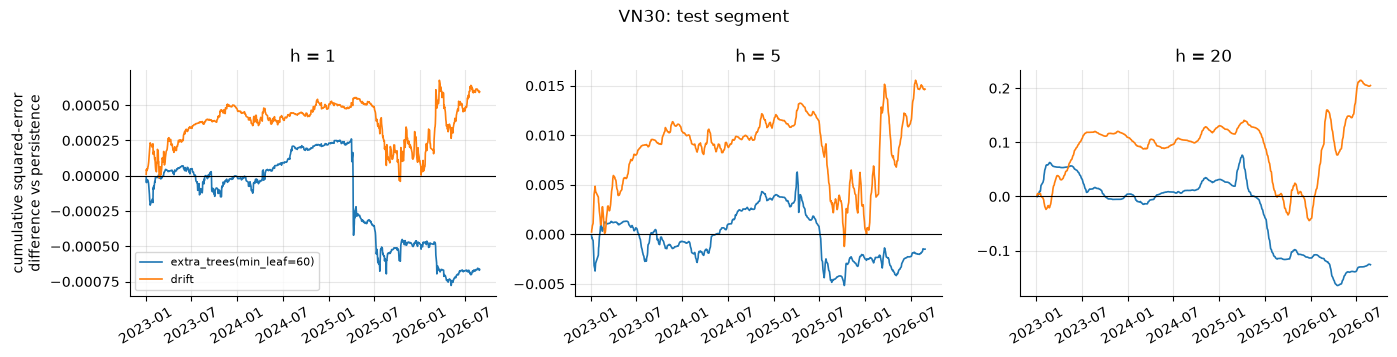

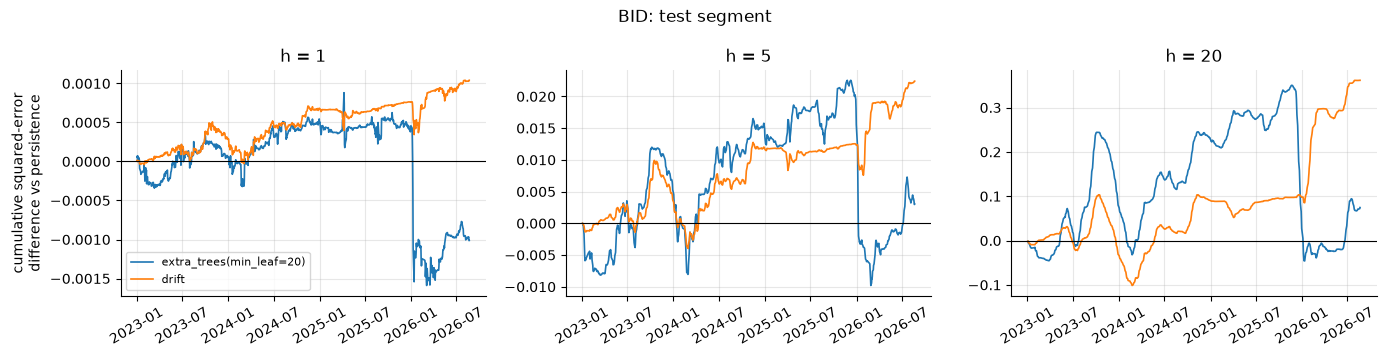

In [5]:
for s in studies:
    t = test[s.name]
    learned = spec_name(choices[s.name]["best_learned"])
    fig, axes = plt.subplots(1, len(s.protocol.horizons), figsize=(14, 3.6))
    for ax, h in zip(axes, s.protocol.horizons):
        dates = t[(t["model"] == learned) & (t["horizon"] == h)]["origin_date"]
        for model in (learned, "drift"):
            d = loss_differential(t, model, "naive", h)
            ax.plot(dates.to_numpy(), d.cumsum().to_numpy(), label=model, lw=1.2)
        ax.axhline(0, color="k", lw=0.8)
        ax.set_title(f"h = {h}")
        ax.tick_params(axis="x", rotation=30)
    axes[0].set_ylabel("cumulative squared-error\ndifference vs persistence")
    axes[0].legend(fontsize=8)
    fig.suptitle(f"{s.name}: test segment")
    fig.tight_layout()
    s.save_figure(fig, "02_cumulative_loss_difference")
    plt.show()

## 5. Stability across calendar years (h = 5)

RMSE ratio to persistence inside each year of the test segment (first and last years may be partial).

In [6]:
from tsresearch.metrics import rmse

for s in studies:
    g = test[s.name][test[s.name]["horizon"] == 5]
    rows = []
    for (model, year), x in g.groupby(["model", g["origin_date"].dt.year]):
        rows.append({"model": model, "year": year, "n": len(x),
                     "rel_rmse": rmse(x["pred"] - x["actual"]) / rmse(x["actual"])})
    by_year = pd.DataFrame(rows)
    print(f"== {s.name}")
    display(by_year.pivot(index="year", columns="model", values="rel_rmse").round(4))
    s.save_table(by_year, "02_by_year_h5")

== VN30


model,drift,extra_trees(min_leaf=60),gradient_boosting(max_depth=2),naive,ridge(alpha=1000.0)
year,,,,,
2023,1.0314,0.9978,0.9937,1.0,1.0102
2024,1.0052,1.0228,1.0049,1.0,0.9936
2025,0.9786,0.9877,0.9977,1.0,0.9902
2026,1.0495,1.0036,0.9916,1.0,0.9958


== BID


model,drift,extra_trees(min_leaf=20),gradient_boosting(max_depth=2),naive,ridge(alpha=1000.0)
year,,,,,
2023,1.0080,1.0115,0.9833,1.0,0.9749
2024,1.0155,1.0161,1.0224,1.0,1.0013
2025,1.0010,1.0032,1.0119,1.0,0.9904
2026,1.0093,0.9882,0.9976,1.0,0.9899


### Findings (committed run)

* **No candidate beats persistence in a statistically convincing way on either dataset.**
  All 12 model-by-horizon comparisons per dataset have a Holm-adjusted p-value of 1, no block
  bootstrap interval excludes zero, and the smallest unadjusted Diebold-Mariano p-value in
  favour of a learned model is 0.29 (VN30, ridge, h = 20) and 0.21 (BID, ridge, h = 5).
* **Validation did not transfer cleanly.** On VN30 persistence itself was the validation winner.
  On BID extra-trees (`min_leaf=20`) won validation (mean ratio 0.994) but on the test segment
  its RMSE ratios are 0.998, 1.001 and 1.007 for h = 1, 5, 20.
* **One pattern repeats on both datasets, without being significant:** ridge (`alpha=1000`) at
  h = 20 has an RMSE ratio of 0.972 (VN30) and 0.977 (BID). With overlapping, dependent
  errors and one test period this is a lead to test on more assets and periods, not a result.
  Directional accuracy of 55-61% at h = 20 should be compared with the base rate of up-moves
  in a rising market before being read as skill.
* **No stable ranking by year.** Year-by-year RMSE ratios at h = 5 move between 0.975 and 1.05.
* The drift forecast has an RMSE ratio above 1 at all three horizons on both datasets.

**Reading.** For daily returns of these two Vietnamese series, with this feature set and
protocol, point forecasts do not improve materially on "no change". The remaining value is
in *quantifying uncertainty*, which is the subject of notebook 03. This is a statement about
these two series, one feature family and one test period, not about market efficiency.